In [22]:
# CELL 1: Imports and Configuration
import numpy as np
import pandas as pd
import rasterio
from rasterio.warp import reproject, Resampling
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from datetime import datetime
from tqdm import tqdm
import os
import pickle
import warnings
warnings.filterwarnings('ignore')

print("="*60)
print("DATA PREPROCESSING PIPELINE")
print("Based on paper Sections 2.2.4 & 4.2")
print("="*60)

# Configuration
class Config:
    # Temporal parameters
    N_TIME_STEPS = 36  # 10-day intervals
    YEAR = 2021
    
    # Spectral bands (Sentinel-2)
    BANDS = ['Blue', 'Green', 'Red', 'Red_Edge_1', 'Red_Edge_2', 
             'Red_Edge_3', 'NIR', 'Red_Edge_4', 'SWIR_1', 'SWIR_2']
    BAND_INDICES = {
        'BLUE': 0, 'GREEN': 1, 'RED': 2,
        'NIR': 6
    }
    
    # Crop codes (California)
    CROP_CODES = {
        36: 'Alfalfa',
        57: 'Rice', 
        69: 'Grapes',
        74: 'Pistachios',
        204: 'Almonds'
    }
    
    # Quality filters
    CDL_CONFIDENCE_THRESHOLD = 95
    WORLDCOVER_CROPLAND_CLASS = 40
    
    # Split ratios
    TRAIN_RATIO = 0.7
    VAL_RATIO = 0.15
    TEST_RATIO = 0.15
    
    # Random seed
    RANDOM_SEED = 42

config = Config()
print(f"\nConfiguration loaded:")
print(f"  Time steps: {config.N_TIME_STEPS}")
print(f"  Bands: {len(config.BANDS)}")
print(f"  Crops: {list(config.CROP_CODES.values())}")

DATA PREPROCESSING PIPELINE
Based on paper Sections 2.2.4 & 4.2

Configuration loaded:
  Time steps: 36
  Bands: 10
  Crops: ['Alfalfa', 'Rice', 'Grapes', 'Pistachios', 'Almonds']


# 2: Path Configuration

In [23]:
# CELL 2: Define Paths
# Update these paths according to your directory structure

# Input paths
RAW_DIR = r"C:\Users\KM-USER\Documents\M1\SII\S2\ResNeur\projectCropClassification\data\raw"
PROCESSED_DIR = r"C:\Users\KM-USER\Documents\M1\SII\S2\ResNeur\projectCropClassification\data\processed\california_preprocessed"

# Create output directories
os.makedirs(PROCESSED_DIR, exist_ok=True)
os.makedirs(os.path.join(PROCESSED_DIR, 'figures'), exist_ok=True)

# Sentinel-2 files
SENTINEL_DIR = os.path.join(RAW_DIR, "california", "sentinel2", "original")
if not os.path.exists(SENTINEL_DIR):
    SENTINEL_DIR = os.path.join(RAW_DIR, "california", "sentinel2")

# CDL files
CDL_FILES = {
    'fresno': os.path.join(RAW_DIR, "california", "cdl", "californiaFresno.tif"),
    'kings': os.path.join(RAW_DIR, "california", "cdl", "californiaKings.tif"),
    'north': os.path.join(RAW_DIR, "california", "cdl", "californiaNorth.tif")
}

# ESA WorldCover
WORLDCOVER_PATH = os.path.join(RAW_DIR, "california", "worldcover", "esa_worldcover_2021.tif")

print("Paths configured:")
print(f"  Sentinel directory: {SENTINEL_DIR}")
print(f"  Output directory: {PROCESSED_DIR}")
print(f"  CDL files: {len(CDL_FILES)}")
print(f"  WorldCover exists: {os.path.exists(WORLDCOVER_PATH)}")

Paths configured:
  Sentinel directory: C:\Users\KM-USER\Documents\M1\SII\S2\ResNeur\projectCropClassification\data\raw\california\sentinel2
  Output directory: C:\Users\KM-USER\Documents\M1\SII\S2\ResNeur\projectCropClassification\data\processed\california_preprocessed
  CDL files: 3
  WorldCover exists: False


# 3: Cloud Filtering Functions

In [24]:
# CELL 3: Cloud Filtering Functions

def filter_clouds_sentinel2(sentinel_data, use_qa_band=False, qa_band=None):
    """
    Filter cloud-affected pixels from Sentinel-2 data.
    Following paper methodology: "eliminated cloud-affected pixels"
    """
    masked_data = sentinel_data.copy().astype(np.float32)
    
    if use_qa_band and qa_band is not None:
        # Use QA band for accurate cloud detection
        # Bit 10 (1024): clouds, Bit 11 (2048): cirrus clouds
        cloud_bit = (qa_band & 1024) != 0
        cirrus_bit = (qa_band & 2048) != 0
        cloud_mask = ~(cloud_bit | cirrus_bit)
    else:
        # Spectral threshold method for cloud detection
        blue_band = sentinel_data[0]  # Band 2
        red_band = sentinel_data[2]   # Band 4
        nir_band = sentinel_data[6]   # Band 8
        
        # Cloud detection thresholds
        cloud_threshold = 0.25  # 25% reflectance
        cloud_pixels = (blue_band > cloud_threshold) & (red_band > cloud_threshold)
        
        # Detect thin clouds using NIR
        thin_cloud_pixels = (nir_band - red_band) < 0.05
        
        cloud_mask = ~(cloud_pixels & thin_cloud_pixels)
    
    # Apply mask (set cloudy pixels to NaN)
    for b in range(sentinel_data.shape[0]):
        masked_data[b][~cloud_mask] = np.nan
    
    return masked_data, cloud_mask

def get_cloud_free_percentage(masked_data):
    """Calculate percentage of cloud-free pixels"""
    valid_pixels = ~np.isnan(masked_data[0])
    return 100 * valid_pixels.sum() / valid_pixels.size

print("✓ Cloud filtering functions defined")

✓ Cloud filtering functions defined


# 4: Time Series Composite Functions

In [25]:
# CELL 4: 10-Day Median Composite Functions

def create_10day_median_composites(sentinel_files_with_dates, year=2021, n_time_steps=36):
    """
    Create 10-day median composites from all Sentinel-2 images.
    ALWAYS returns n_time_steps (continuous sequence).
    Missing data = NaN (will be set to 0 later)
    """
    from datetime import datetime, timedelta
    
    # Create 10-day intervals
    start_date = datetime(year, 1, 1)
    end_date = datetime(year, 12, 31)
    
    intervals = []
    current = start_date
    while current <= end_date:
        intervals.append(current)
        current += timedelta(days=10)
    
    n_intervals = len(intervals) - 1
    print(f"Creating {n_intervals} ten-day intervals for year {year}")
    
    # Load first file to get dimensions
    with rasterio.open(sentinel_files_with_dates[0][0]) as src:
        n_bands = src.count
        height, width = src.shape
    
    # Initialize composites array
    composites = np.full((n_intervals, n_bands, height, width), np.nan, dtype=np.float32)
    composite_dates = []
    
    # Process each interval
    for i in tqdm(range(n_intervals), desc="Creating composites"):
        interval_start = intervals[i]
        interval_end = intervals[i+1]
        composite_dates.append(interval_start)
        
        # Collect images in this interval
        interval_data = []
        
        for file_path, acq_date in sentinel_files_with_dates:
            if interval_start <= acq_date < interval_end:
                with rasterio.open(file_path) as src:
                    data = src.read().astype(np.float32)
                    
                    # Apply cloud filtering
                    masked_data, _ = filter_clouds_sentinel2(data)
                    
                    # Check if any valid data
                    if not np.all(np.isnan(masked_data[0])):
                        interval_data.append(masked_data)
        
        # Compute median composite
        if interval_data:
            stacked = np.stack(interval_data, axis=0)
            median_composite = np.nanmedian(stacked, axis=0)
            composites[i] = median_composite
    
    print(f"✓ Created {n_intervals} composites")
    return composites, composite_dates

def extract_pixel_time_series(composites, coordinates):
    """
    Extract time series for pixel coordinates.
    Returns: (n_pixels, n_time, n_bands)
    """
    n_time = composites.shape[0]
    n_bands = composites.shape[1]
    n_pixels = len(coordinates)
    
    X = np.zeros((n_pixels, n_time, n_bands), dtype=np.float32)
    masks = np.zeros((n_pixels, n_time, n_bands), dtype=np.float32)
    
    for p, (row, col) in enumerate(tqdm(coordinates, desc="Extracting pixels")):
        for t in range(n_time):
            for b in range(n_bands):
                value = composites[t, b, row, col]
                if not np.isnan(value):
                    X[p, t, b] = value
                    masks[p, t, b] = 1.0
                # Else remains 0 (missing data marked as 0)
    
    return X, masks

print("✓ Time series functions defined")

✓ Time series functions defined


# 5: Vegetation Indices Functions

In [26]:
# CELL 5: Vegetation Indices Functions

def compute_ndvi(red_band, nir_band, epsilon=1e-10):
    """NDVI = (NIR - Red) / (NIR + Red + epsilon)"""
    numerator = nir_band - red_band
    denominator = nir_band + red_band + epsilon
    return numerator / denominator

def compute_ndwi(green_band, nir_band, epsilon=1e-10):
    """NDWI = (Green - NIR) / (Green + NIR + epsilon)"""
    numerator = green_band - nir_band
    denominator = green_band + nir_band + epsilon
    return numerator / denominator

def compute_evi(blue_band, red_band, nir_band, G=2.5, C1=6.0, C2=7.5, L=1.0, epsilon=1e-10):
    """EVI = G * (NIR - Red) / (NIR + C1*Red - C2*Blue + L + epsilon)"""
    numerator = G * (nir_band - red_band)
    denominator = nir_band + C1 * red_band - C2 * blue_band + L + epsilon
    return numerator / denominator

def add_vegetation_indices(X, band_indices):
    """
    Add vegetation indices to feature array.
    Returns: X_augmented (n_samples, n_time, n_bands+3), index_names
    """
    n_samples, n_time, n_bands = X.shape
    
    blue_idx = band_indices['BLUE']
    green_idx = band_indices['GREEN']
    red_idx = band_indices['RED']
    nir_idx = band_indices['NIR']
    
    # Initialize arrays for indices
    ndvi = np.zeros((n_samples, n_time))
    ndwi = np.zeros((n_samples, n_time))
    evi = np.zeros((n_samples, n_time))
    
    # Compute indices for each sample
    for i in range(n_samples):
        blue = X[i, :, blue_idx]
        green = X[i, :, green_idx]
        red = X[i, :, red_idx]
        nir = X[i, :, nir_idx]
        
        ndvi[i, :] = compute_ndvi(red, nir)
        ndwi[i, :] = compute_ndwi(green, nir)
        evi[i, :] = compute_evi(blue, red, nir)
    
    # Clip to valid ranges
    ndvi = np.clip(ndvi, -1, 1)
    ndwi = np.clip(ndwi, -1, 1)
    
    # Add as new bands
    X_augmented = np.concatenate([
        X,
        ndvi[:, :, np.newaxis],
        ndwi[:, :, np.newaxis],
        evi[:, :, np.newaxis]
    ], axis=2)
    
    return X_augmented, ['NDVI', 'NDWI', 'EVI']

print("✓ Vegetation indices functions defined")

✓ Vegetation indices functions defined


# 6: CDL and Label Processing Functions

In [27]:
# CELL 6: CDL and Label Processing Functions

def load_cdl_data(cdl_path, apply_confidence_filter=True, threshold=95):
    """Load CDL data and apply confidence filter"""
    with rasterio.open(cdl_path) as src:
        cdl_data = src.read(1)
        transform = src.transform
        crs = src.crs
    
    # Apply confidence filter
    if apply_confidence_filter:
        try:
            with rasterio.open(cdl_path) as src:
                if src.count >= 2:
                    confidence = src.read(2)
                    cdl_data[confidence < threshold] = 0
                    print(f"  Applied {threshold}% confidence filter")
        except:
            print("  Warning: Confidence layer not available")
    
    return cdl_data, transform, crs

def apply_worldcover_mask(cdl_data, worldcover_path, target_transform, target_crs, cropland_class=40):
    """Mask non-cropland using ESA WorldCover"""
    with rasterio.open(worldcover_path) as src:
        worldcover_resampled = np.zeros_like(cdl_data)
        reproject(
            source=src.read(1),
            destination=worldcover_resampled,
            src_transform=src.transform,
            src_crs=src.crs,
            dst_transform=target_transform,
            dst_crs=target_crs,
            resampling=Resampling.nearest
        )
    
    cropland_mask = worldcover_resampled == cropland_class
    print(f"  Cropland pixels: {cropland_mask.sum():,}")
    return cropland_mask

def extract_labels(cdl_data, coordinates):
    """Extract crop labels for given pixel coordinates"""
    labels = np.array([cdl_data[row, col] for row, col in coordinates])
    return labels

print("✓ CDL processing functions defined")

✓ CDL processing functions defined


# 7: Normalization and Missing Data Handling

In [28]:
# CELL 7: Normalization and Missing Data Handling

def normalize_data(composites, scale_factor=10000):
    """Normalize reflectance values by dividing by 10000"""
    return composites / scale_factor

def handle_missing_data(composites, fill_value=0):
    """
    Handle missing data: replace NaN with fill_value
    NO interpolation as per paper methodology
    Also creates ALPE mask (1=data, 0=missing)
    """
    alpe_mask = ~np.isnan(composites)
    composites_filled = np.nan_to_num(composites, nan=fill_value)
    return composites_filled, alpe_mask.astype(np.float32)

def verify_continuous_sequence(X, masks, expected_time_steps=36):
    """Verify that all sequences have exactly expected_time_steps"""
    assert X.shape[1] == expected_time_steps, f"Expected {expected_time_steps} time steps, got {X.shape[1]}"
    assert masks.shape[1] == expected_time_steps, f"Expected {expected_time_steps} time steps in mask"
    
    # Check missing data marking
    zero_values = X[masks == 0]
    valid_values = X[masks == 1]
    
    results = {
        'correct_time_steps': True,
        'missing_marked_as_0': np.all(zero_values == 0) if len(zero_values) > 0 else True,
        'valid_data_positive': np.all(valid_values > 0) if len(valid_values) > 0 else True,
        'missing_rate': 1 - masks.mean()
    }
    
    print(f"\n✓ Sequence verification:")
    print(f"  - All {X.shape[0]} samples have {X.shape[1]} time steps")
    print(f"  - Missing data marked as 0: {results['missing_marked_as_0']}")
    print(f"  - Missing rate: {results['missing_rate']*100:.2f}%")
    
    return results

print("✓ Normalization and missing data handling functions defined")

✓ Normalization and missing data handling functions defined


#  8: Main Preprocessing Pipeline

In [29]:
# CELL 8: Main Preprocessing Pipeline

def preprocess_region(sentinel_files_with_dates, cdl_path, region_name, 
                      crops_to_keep, worldcover_path=None, max_samples=5000):
    """
    Complete preprocessing pipeline for one region.
    
    Steps (from paper):
    1. Create 10-day median composites (36 time steps)
    2. Apply cloud filtering
    3. Normalize (divide by 10000)
    4. Mark missing data as 0 (NO interpolation)
    5. Create ALPE masks
    6. Extract samples from CDL-labeled pixels
    7. Add vegetation indices
    """
    
    print(f"\n{'='*70}")
    print(f"PREPROCESSING {region_name.upper()}")
    print(f"{'='*70}")
    
    # Step 1-2: Create 10-day composites with cloud filtering
    print("\n[Step 1-2] Creating 10-day median composites...")
    composites, composite_dates = create_10day_median_composites(
        sentinel_files_with_dates, year=config.YEAR
    )
    print(f"  Composites shape: {composites.shape}")
    
    # Step 3: Normalization
    print("\n[Step 3] Normalizing data...")
    composites = normalize_data(composites)
    
    # Step 4-5: Handle missing data and create ALPE mask
    print("\n[Step 4-5] Handling missing data (NO interpolation)...")
    composites, alpe_mask = handle_missing_data(composites)
    
    # Load CDL data
    print("\n[Step 6] Loading CDL data...")
    cdl_data, cdl_transform, cdl_crs = load_cdl_data(
        cdl_path, apply_confidence_filter=True, threshold=config.CDL_CONFIDENCE_THRESHOLD
    )
    print(f"  CDL shape: {cdl_data.shape}")
    
    # Load WorldCover for masking non-cropland
    if worldcover_path and os.path.exists(worldcover_path):
        print("\n  Loading ESA WorldCover...")
        cropland_mask = apply_worldcover_mask(
            cdl_data, worldcover_path, cdl_transform, cdl_crs,
            cropland_class=config.WORLDCOVER_CROPLAND_CLASS
        )
    else:
        print("\n  WorldCover not found - using all CDL pixels")
        cropland_mask = np.ones_like(cdl_data, dtype=bool)
    
    # Find valid pixels
    print("\n[Step 7] Finding valid cropland pixels...")
    valid_cdl = np.isin(cdl_data, crops_to_keep)
    valid_mask = valid_cdl & cropland_mask
    valid_rows, valid_cols = np.where(valid_mask)
    print(f"  Found {len(valid_rows):,} valid cropland pixels")
    
    # Sample pixels
    if len(valid_rows) > max_samples:
        np.random.seed(config.RANDOM_SEED)
        sample_idx = np.random.choice(len(valid_rows), max_samples, replace=False)
        valid_rows = valid_rows[sample_idx]
        valid_cols = valid_cols[sample_idx]
    
    sample_coords = list(zip(valid_rows, valid_cols))
    
    # Extract time series
    print("\n[Step 8] Extracting pixel time series...")
    X, masks = extract_pixel_time_series(composites, sample_coords)
    
    # Extract labels
    y = extract_labels(cdl_data, sample_coords)
    
    # Add vegetation indices
    print("\n[Step 9] Adding vegetation indices...")
    X_augmented, index_names = add_vegetation_indices(X, config.BAND_INDICES)
    
    # Verify continuous sequence
    print("\n[Step 10] Verifying continuous sequence...")
    verify_continuous_sequence(X_augmented, masks)
    
    print(f"\n✓ Preprocessing complete for {region_name}!")
    print(f"  X shape: {X_augmented.shape}")
    print(f"  y shape: {y.shape}")
    print(f"  Added indices: {index_names}")
    
    return X_augmented, masks, y

print("✓ Main preprocessing pipeline defined")

✓ Main preprocessing pipeline defined


# 9: Load Existing Data (If Available)

In [30]:
# CELL 9: Load Balanced Data from Notebook 2b

print("\n" + "="*70)
print("LOADING BALANCED DATA FROM NOTEBOOK 2b")
print("="*70)

# Path to balanced data from Notebook 2b
BALANCED_DATA_DIR = r"C:\Users\KM-USER\Documents\M1\SII\S2\ResNeur\projectCropClassification\data\processed\california_balanced"

# Check if balanced data exists
if os.path.exists(os.path.join(BALANCED_DATA_DIR, 'X_balanced.npy')):
    # Load balanced data
    X = np.load(os.path.join(BALANCED_DATA_DIR, 'X_balanced.npy'))
    y = np.load(os.path.join(BALANCED_DATA_DIR, 'y_balanced.npy'))
    masks = np.load(os.path.join(BALANCED_DATA_DIR, 'masks_balanced.npy'))
    
    # Load metadata if available
    metadata_path = os.path.join(BALANCED_DATA_DIR, 'balanced_metadata.pkl')
    if os.path.exists(metadata_path):
        with open(metadata_path, 'rb') as f:
            metadata = pickle.load(f)
        print(f"\n✅ Balanced data loaded successfully!")
        print(f"  Metadata: {metadata.get('sampling_strategy', 'Unknown')}")
    else:
        print(f"\n✅ Balanced data loaded successfully!")
    
    print(f"  X shape: {X.shape}")
    print(f"  y shape: {y.shape}")
    print(f"  masks shape: {masks.shape}")
    
    # Verify class distribution (should be balanced)
    print(f"\n📊 Class distribution (should be balanced):")
    unique_codes, counts = np.unique(y, return_counts=True)
    for code, count in zip(unique_codes, counts):
        name = config.CROP_CODES.get(code, f'Crop_{code}')
        print(f"  {name:12}: {count:5,} samples")
    
    # Verify all classes have same/similar counts
    if len(np.unique(counts)) == 1:
        print(f"\n  ✅ PERFECTLY BALANCED! All classes have {counts[0]} samples")
    elif max(counts) - min(counts) <= counts[0] * 0.1:  # Within 10%
        print(f"\n  ✅ WELL BALANCED! Samples per class: {min(counts)} - {max(counts)}")
    else:
        print(f"\n  ⚠️ WARNING: Data may not be balanced! Samples per class: {dict(zip(unique_codes, counts))}")
    
    data_loaded = True
    
else:
    print("\n❌ Balanced data not found!")
    print(f"   Looking for: {BALANCED_DATA_DIR}")
    print("\n   Please run Notebook 2b first to create balanced dataset.")
    print("   Or check if the path is correct.")
    
    # Fallback to original data
    NOTEBOOK1_DATA_DIR = r"C:\Users\KM-USER\Documents\M1\SII\S2\ResNeur\projectCropClassification\data\processed\california"
    
    if os.path.exists(os.path.join(NOTEBOOK1_DATA_DIR, 'X.npy')):
        print("\n⚠️ Falling back to original unbalanced data...")
        X = np.load(os.path.join(NOTEBOOK1_DATA_DIR, 'X.npy'))
        y = np.load(os.path.join(NOTEBOOK1_DATA_DIR, 'y.npy'))
        masks = np.load(os.path.join(NOTEBOOK1_DATA_DIR, 'masks.npy'))
        data_loaded = True
        print("  Using UNBALANCED data. Consider running Notebook 2b first.")
    else:
        data_loaded = False
        X, y, masks = None, None, None

# Store in variables
X_data = X
y_data = y
masks_data = masks


LOADING BALANCED DATA FROM NOTEBOOK 2b

✅ Balanced data loaded successfully!
  Metadata: balanced
  X shape: (10487, 36, 10)
  y shape: (10487,)
  masks shape: (10487, 36, 10)

📊 Class distribution (should be balanced):
  Alfalfa     : 4,000 samples
  Rice        :   112 samples
  Grapes      : 4,000 samples
  Pistachios  :   446 samples
  Almonds     : 1,929 samples

  ⚠️ WARNING: Data may not be balanced! Samples per class: {np.uint8(36): np.int64(4000), np.uint8(57): np.int64(112), np.uint8(69): np.int64(4000), np.uint8(74): np.int64(446), np.uint8(204): np.int64(1929)}


# 10: Combine Regions

In [31]:
# CELL 10: Combine Regions (Updated for balanced data)

print("\n" + "="*70)
print("PREPARING BALANCED DATA FOR PREPROCESSING")
print("="*70)

if data_loaded:
    # Use balanced data directly
    X_combined = X_data
    masks_combined = masks_data
    y_combined = y_data
    
    print(f"\nUsing balanced dataset:")
    print(f"  X_combined shape: {X_combined.shape}")
    print(f"  y_combined shape: {y_combined.shape}")
    print(f"  masks_combined shape: {masks_combined.shape}")
    
    # Show class distribution
    unique_codes, counts = np.unique(y_combined, return_counts=True)
    print(f"\nClass distribution (balanced):")
    for code, count in zip(unique_codes, counts):
        name = config.CROP_CODES.get(code, f'Crop_{code}')
        print(f"  {name:12}: {count:5,} samples")
else:
    print("\nNo data loaded. Cannot proceed.")
    X_combined, masks_combined, y_combined = None, None, None


PREPARING BALANCED DATA FOR PREPROCESSING

Using balanced dataset:
  X_combined shape: (10487, 36, 10)
  y_combined shape: (10487,)
  masks_combined shape: (10487, 36, 10)

Class distribution (balanced):
  Alfalfa     : 4,000 samples
  Rice        :   112 samples
  Grapes      : 4,000 samples
  Pistachios  :   446 samples
  Almonds     : 1,929 samples


In [32]:
# Quick check cell to verify balanced data location
import os

BALANCED_DIR = r"C:\Users\KM-USER\Documents\M1\SII\S2\ResNeur\projectCropClassification\data\processed\california_balanced"

print("Checking for balanced data files:")
print(f"Directory: {BALANCED_DIR}")
print(f"Exists: {os.path.exists(BALANCED_DIR)}")

if os.path.exists(BALANCED_DIR):
    files = os.listdir(BALANCED_DIR)
    print(f"\nFiles found:")
    for f in files:
        if f.endswith('.npy') or f.endswith('.pkl'):
            print(f"  - {f}")
else:
    print("\n❌ Balanced data directory not found!")
    print("Please check Notebook 2b output path.")

Checking for balanced data files:
Directory: C:\Users\KM-USER\Documents\M1\SII\S2\ResNeur\projectCropClassification\data\processed\california_balanced
Exists: True

Files found:
  - balanced_indices.npy
  - balanced_metadata.pkl
  - masks_balanced.npy
  - X_balanced.npy
  - y_balanced.npy


# 11: Add Vegetation Indices (If Needed)

In [33]:
# CELL 11: Add Vegetation Indices - CORRECTED VERSION

def normalize_bands_safely(X, scale_factor=10000):
    """Normalize reflectance bands (not vegetation indices)"""
    # Only normalize if values are > 1 (raw reflectance)
    if X.max() > 1:
        print(f"  Normalizing raw reflectance (max={X.max():.2f}) by dividing by {scale_factor}")
        X_normalized = X / scale_factor
    else:
        print(f"  Data already normalized (max={X.max():.4f})")
        X_normalized = X
    return X_normalized

def add_indices_safely(X, masks, band_indices):
    """Add vegetation indices with proper NaN handling"""
    print("\n" + "="*70)
    print("ADDING VEGETATION INDICES")
    print("="*70)
    
    # Check for NaNs
    nan_count = np.isnan(X).sum()
    if nan_count > 0:
        print(f"\n⚠️ Found {nan_count} NaN values! Replacing with 0...")
        X = np.nan_to_num(X, nan=0.0)
    
    # NORMALIZE PROPERLY using the safe function
    print(f"\n[Step 1] Checking normalization...")
    X = normalize_bands_safely(X, scale_factor=10000)
    
    # Verify NDVI range after normalization
    red_idx = band_indices['RED']
    nir_idx = band_indices['NIR']
    test_ndvi = compute_ndvi(X[:, :, red_idx], X[:, :, nir_idx])
    print(f"  Test NDVI range after normalization: [{test_ndvi.min():.4f}, {test_ndvi.max():.4f}]")
    
    # Add vegetation indices
    print(f"\n[Step 2] Computing vegetation indices for {X.shape[0]} samples...")
    X_augmented, index_names = add_vegetation_indices(X, band_indices)
    
    # Final check
    total_nans = np.isnan(X_augmented).sum()
    if total_nans > 0:
        print(f"\n⚠️ Found {total_nans} NaN values! Replacing...")
        X_augmented = np.nan_to_num(X_augmented, nan=0.0)
    else:
        print(f"\n✅ No NaN values in X_augmented")
    
    # Verify final NDVI range
    ndvi = X_augmented[:, :, -3]
    evi = X_augmented[:, :, -1]
    print(f"\n✅ Vegetation indices added:")
    print(f"  X shape: {X_augmented.shape}")
    print(f"  Added indices: {index_names}")
    print(f"  NDVI range: [{ndvi.min():.4f}, {ndvi.max():.4f}] (should be between -1 and 1)")
    print(f"  EVI range: [{evi.min():.4f}, {evi.max():.4f}] (can be >1)")
    
    # Sanity check
    if ndvi.min() < -1.1 or ndvi.max() > 1.1:
        print(f"  ⚠️ WARNING: NDVI outside expected range [-1, 1]!")
    else:
        print(f"  ✓ NDVI range is correct!")
    
    return X_augmented

# Add indices if not already present
if X_combined.shape[2] == 10:  # Only original bands
    X_combined = add_indices_safely(X_combined, masks_combined, config.BAND_INDICES)
else:
    print(f"\nVegetation indices already present (total bands: {X_combined.shape[2]})")


ADDING VEGETATION INDICES

⚠️ Found 296870 NaN values! Replacing with 0...

[Step 1] Checking normalization...
  Data already normalized (max=0.7280)
  Test NDVI range after normalization: [-0.9256, 1.0000]

[Step 2] Computing vegetation indices for 10487 samples...

✅ No NaN values in X_augmented

✅ Vegetation indices added:
  X shape: (10487, 36, 13)
  Added indices: ['NDVI', 'NDWI', 'EVI']
  NDVI range: [-0.9256, 1.0000] (should be between -1 and 1)
  EVI range: [-17.0812, 76.6212] (can be >1)
  ✓ NDVI range is correct!


# 12: Remove Rare Classes

In [34]:
# CELL 12: Remove Rare Classes (e.g., Pistachios)

print("\n" + "="*70)
print("FILTERING RARE CLASSES")
print("="*70)

# Count samples per class
unique_codes, counts = np.unique(y_combined, return_counts=True)
print("\nCurrent class distribution:")
for code, count in zip(unique_codes, counts):
    name = config.CROP_CODES.get(code, f'Crop_{code}')
    print(f"  {name:12}: {count:5,} samples")

# Define minimum samples per class
MIN_SAMPLES = 10

# Filter rare classes
rare_classes = [code for code, count in zip(unique_codes, counts) if count < MIN_SAMPLES]

if rare_classes:
    print(f"\n✓ Removing rare classes: {[config.CROP_CODES.get(c, c) for c in rare_classes]}")
    mask = ~np.isin(y_combined, rare_classes)
    X_combined = X_combined[mask]
    y_combined = y_combined[mask]
    masks_combined = masks_combined[mask]
    
    # Updated distribution
    unique_codes, counts = np.unique(y_combined, return_counts=True)
    print("\nUpdated class distribution:")
    for code, count in zip(unique_codes, counts):
        name = config.CROP_CODES.get(code, f'Crop_{code}')
        print(f"  {name:12}: {count:5,} samples")
else:
    print("\n✓ All classes have sufficient samples")


FILTERING RARE CLASSES

Current class distribution:
  Alfalfa     : 4,000 samples
  Rice        :   112 samples
  Grapes      : 4,000 samples
  Pistachios  :   446 samples
  Almonds     : 1,929 samples

✓ All classes have sufficient samples


# 13: Train/Validation/Test Split

In [35]:
# CELL 13: Train/Validation/Test Split (EXACTEMENT comme dans l'article)
# Basé sur le tableau de l'article:

# California:
# - Training: 240 par classe (total 1,440)
# - Validation: 60 par classe (total 360)
# - Test: Le reste (total 8,200)

print("\n" + "="*70)
print("TRAIN/VALIDATION/TEST SPLIT (EXACTEMENT ARTICLE)")
print("="*70)

np.random.seed(42)

# Paramètres EXACTS de l'article pour la Californie
TRAIN_PER_CLASS = 240
VAL_PER_CLASS = 60
# Test = tout le reste

train_idx_list = []
val_idx_list = []
test_idx_list = []

print(f"\nSampling {TRAIN_PER_CLASS} train + {VAL_PER_CLASS} val per class...")
print("-" * 50)

for crop_code in unique_codes:
    crop_name = config.CROP_CODES.get(crop_code, f'Crop_{crop_code}')
    
    # Récupérer tous les indices de cette classe
    crop_indices = np.where(y_combined == crop_code)[0]
    total_crop = len(crop_indices)
    
    # Vérifier qu'on a assez d'échantillons
    if total_crop < TRAIN_PER_CLASS + VAL_PER_CLASS:
        print(f"  ⚠️ {crop_name}: seulement {total_crop} échantillons (moins que requis)")
        n_train = min(TRAIN_PER_CLASS, total_crop // 2)
        n_val = min(VAL_PER_CLASS, total_crop - n_train)
    else:
        n_train = TRAIN_PER_CLASS
        n_val = VAL_PER_CLASS
    
    # Mélanger et sélectionner
    shuffled = np.random.permutation(crop_indices)
    train_idx_class = shuffled[:n_train]
    val_idx_class = shuffled[n_train:n_train + n_val]
    test_idx_class = shuffled[n_train + n_val:]
    
    train_idx_list.extend(train_idx_class)
    val_idx_list.extend(val_idx_class)
    test_idx_list.extend(test_idx_class)
    
    print(f"  {crop_name:12}: total={total_crop:4}, train={n_train:3}, val={n_val:3}, test={len(test_idx_class):4}")

train_idx = np.array(train_idx_list)
val_idx = np.array(val_idx_list)
test_idx = np.array(test_idx_list)

print("\n" + "="*70)
print("SPLIT RESULTS")
print("="*70)
print(f"  Training samples:   {len(train_idx):,}")
print(f"  Validation samples: {len(val_idx):,}")
print(f"  Test samples:       {len(test_idx):,}")
print(f"  Total:              {len(train_idx) + len(val_idx) + len(test_idx):,}")

# Comparaison avec l'article
print("\n" + "="*70)
print("COMPARAISON AVEC L'ARTICLE")
print("="*70)
print(f"  Article - Train: 1,440 | Notre Train: {len(train_idx)}")
print(f"  Article - Val:   360   | Notre Val:   {len(val_idx)}")
print(f"  Article - Test:  8,200 | Notre Test:  {len(test_idx)}")


TRAIN/VALIDATION/TEST SPLIT (EXACTEMENT ARTICLE)

Sampling 240 train + 60 val per class...
--------------------------------------------------
  Alfalfa     : total=4000, train=240, val= 60, test=3700
  ⚠️ Rice: seulement 112 échantillons (moins que requis)
  Rice        : total= 112, train= 56, val= 56, test=   0
  Grapes      : total=4000, train=240, val= 60, test=3700
  Pistachios  : total= 446, train=240, val= 60, test= 146
  Almonds     : total=1929, train=240, val= 60, test=1629

SPLIT RESULTS
  Training samples:   1,016
  Validation samples: 296
  Test samples:       9,175
  Total:              10,487

COMPARAISON AVEC L'ARTICLE
  Article - Train: 1,440 | Notre Train: 1016
  Article - Val:   360   | Notre Val:   296
  Article - Test:  8,200 | Notre Test:  9175


#  14: Visualize NDVI Profiles


VISUALIZATION - NDVI PROFILES
X_ndvi shape: (10487, 36)
X_ndvi range: [-0.9256, 1.0000]


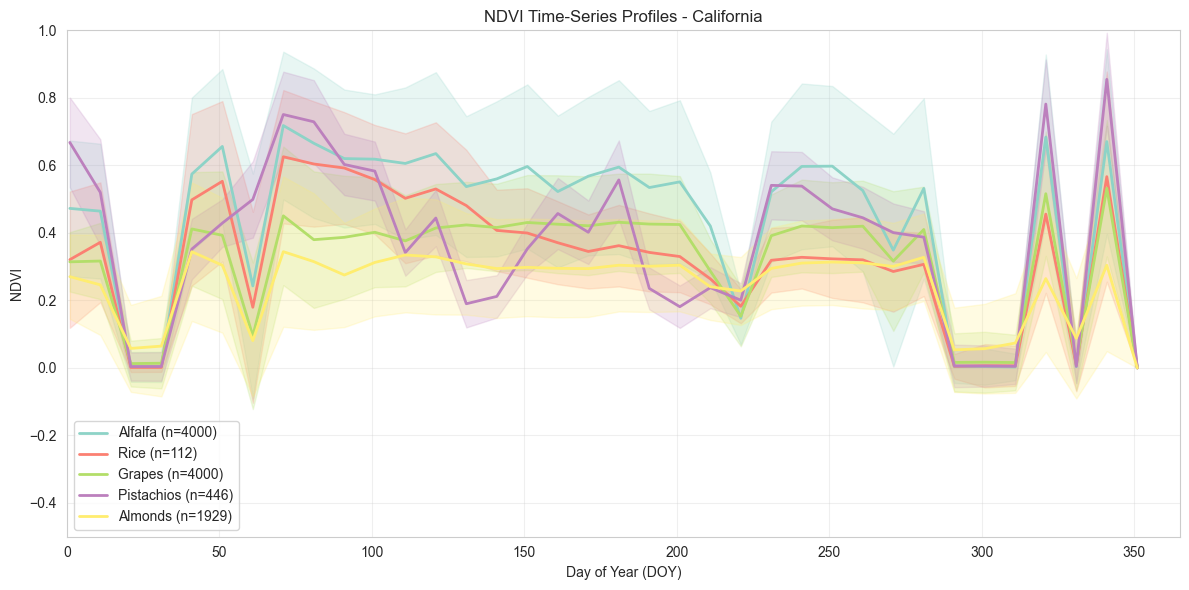


✓ NDVI profile saved to C:\Users\KM-USER\Documents\M1\SII\S2\ResNeur\projectCropClassification\data\processed\california_preprocessed\figures\ndvi_profiles.png


In [36]:
# CELL 14: Visualize NDVI Profiles (Paper Figure 2) - FIXED

import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['figure.figsize'] = (12, 6)
sns.set_style("whitegrid")

print("\n" + "="*70)
print("VISUALIZATION - NDVI PROFILES")
print("="*70)

# Extract NDVI (last added index)
if X_combined.shape[2] > 10:
    X_ndvi = X_combined[:, :, -3]
else:
    # If no indices added, compute from bands
    red_idx = config.BAND_INDICES['RED']
    nir_idx = config.BAND_INDICES['NIR']
    X_ndvi = compute_ndvi(X_combined[:, :, red_idx], X_combined[:, :, nir_idx])

DOY = np.arange(1, 361, 10)[:config.N_TIME_STEPS]

print(f"X_ndvi shape: {X_ndvi.shape}")
print(f"X_ndvi range: [{X_ndvi.min():.4f}, {X_ndvi.max():.4f}]")

# Get unique classes
unique_codes = np.unique(y_combined)

fig, ax = plt.subplots(figsize=(12, 6))
colors = plt.cm.Set3(np.linspace(0, 1, len(unique_codes)))

for idx, code in enumerate(unique_codes):
    mask = (y_combined == code)
    name = config.CROP_CODES.get(code, f'Crop_{code}')
    
    if not np.any(mask):
        continue
    
    crop_ndvi = X_ndvi[mask]
    mean_ndvi = np.mean(crop_ndvi, axis=0)
    std_ndvi = np.std(crop_ndvi, axis=0)
    
    ax.plot(DOY, mean_ndvi, label=f'{name} (n={len(crop_ndvi)})', 
            color=colors[idx], linewidth=2)
    ax.fill_between(DOY, mean_ndvi - std_ndvi, mean_ndvi + std_ndvi, 
                    alpha=0.2, color=colors[idx])

ax.set_xlabel('Day of Year (DOY)')
ax.set_ylabel('NDVI')
ax.set_title('NDVI Time-Series Profiles - California')
ax.legend(loc='best')
ax.grid(True, alpha=0.3)
ax.set_ylim(-0.5, 1.0)
ax.set_xlim(0, 365)

plt.tight_layout()
plt.savefig(os.path.join(PROCESSED_DIR, 'figures', 'ndvi_profiles.png'), dpi=300)
plt.show()

print(f"\n✓ NDVI profile saved to {os.path.join(PROCESSED_DIR, 'figures', 'ndvi_profiles.png')}")

#  15: Save Preprocessed Data

In [37]:
# CELL 14.5: Encode labels (si pas déjà fait)
from sklearn.preprocessing import LabelEncoder

# Créer et encoder les labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y_combined)

print("=" * 70)
print("LABEL ENCODING")
print("=" * 70)
print(f"Classes originales: {np.unique(y_combined)}")
print(f"Classes encodées: {np.unique(y_encoded)}")
print(f"Mapping: {dict(zip(label_encoder.classes_, range(len(label_encoder.classes_))))}")

LABEL ENCODING
Classes originales: [ 36  57  69  74 204]
Classes encodées: [0 1 2 3 4]
Mapping: {np.uint8(36): 0, np.uint8(57): 1, np.uint8(69): 2, np.uint8(74): 3, np.uint8(204): 4}


In [38]:
# CELL 15: Save Final Preprocessed Data

print("\n" + "="*70)
print("SAVING FINAL PREPROCESSED DATA")
print("="*70)

# S'assurer que y_combined est encodé
if 'label_encoder' not in dir():
    from sklearn.preprocessing import LabelEncoder
    label_encoder = LabelEncoder()
    y_encoded = label_encoder.fit_transform(y_combined)
else:
    y_encoded = label_encoder.transform(y_combined)

# Final verification
print("\n[FINAL VERIFICATION]")

# Check for NaNs
nan_count = np.isnan(X_combined).sum()
if nan_count > 0:
    print(f"  ⚠️ CRITICAL: {nan_count} NaN values found! Replacing...")
    X_combined = np.nan_to_num(X_combined, nan=0.0)
else:
    print(f"  ✓ No NaN values in X_combined")

# Check data range
print(f"  X range: [{X_combined.min():.6f}, {X_combined.max():.6f}]")

# Extract NDVI for range check
if X_combined.shape[2] > 10:
    X_ndvi_final = X_combined[:, :, -3]
else:
    red_idx = config.BAND_INDICES['RED']
    nir_idx = config.BAND_INDICES['NIR']
    X_ndvi_final = compute_ndvi(X_combined[:, :, red_idx], X_combined[:, :, nir_idx])
print(f"  NDVI range: [{X_ndvi_final.min():.6f}, {X_ndvi_final.max():.6f}]")

# Save data
np.save(os.path.join(PROCESSED_DIR, 'X.npy'), X_combined)
np.save(os.path.join(PROCESSED_DIR, 'y.npy'), y_encoded)  # ← Utiliser y_encoded
np.save(os.path.join(PROCESSED_DIR, 'masks.npy'), masks_combined)
np.save(os.path.join(PROCESSED_DIR, 'train_indices.npy'), train_idx)
np.save(os.path.join(PROCESSED_DIR, 'val_indices.npy'), val_idx)
np.save(os.path.join(PROCESSED_DIR, 'test_indices.npy'), test_idx)

# Save label encoder classes
label_classes = label_encoder.classes_.tolist()

# Save metadata
metadata = {
    'crop_names': config.CROP_CODES,
    'band_names': config.BANDS,
    'added_indices': ['NDVI', 'NDWI', 'EVI'],
    'normalization': 'divided_by_10000',
    'normalization_scale': 10000,  
    'label_encoder_classes': label_classes,
    'doy': DOY.tolist(),
    'n_samples': len(y_encoded),
    'n_time_steps': config.N_TIME_STEPS,
    'n_bands': X_combined.shape[2],
    'mean_missing_rate': float(1 - masks_combined.mean()),
    'train_samples': len(train_idx),
    'val_samples': len(val_idx),
    'test_samples': len(test_idx),
    'x_min': float(X_combined.min()),
    'x_max': float(X_combined.max()),
    'ndvi_min': float(X_ndvi_final.min()),
    'ndvi_max': float(X_ndvi_final.max()),
    'random_seed': config.RANDOM_SEED
}

with open(os.path.join(PROCESSED_DIR, 'metadata.pkl'), 'wb') as f:
    pickle.dump(metadata, f)

print(f"\n✅ Data saved to: {PROCESSED_DIR}")
print(f"\nFiles saved:")
print(f"  - X.npy: {X_combined.shape}")
print(f"  - y.npy: {y_encoded.shape}")
print(f"  - masks.npy: {masks_combined.shape}")
print(f"  - train_indices.npy: {len(train_idx)}")
print(f"  - val_indices.npy: {len(val_idx)}")
print(f"  - test_indices.npy: {len(test_idx)}")
print(f"  - metadata.pkl")


SAVING FINAL PREPROCESSED DATA

[FINAL VERIFICATION]
  ✓ No NaN values in X_combined
  X range: [-17.081173, 76.621239]
  NDVI range: [-0.925616, 1.000000]

✅ Data saved to: C:\Users\KM-USER\Documents\M1\SII\S2\ResNeur\projectCropClassification\data\processed\california_preprocessed

Files saved:
  - X.npy: (10487, 36, 13)
  - y.npy: (10487,)
  - masks.npy: (10487, 36, 10)
  - train_indices.npy: 1016
  - val_indices.npy: 296
  - test_indices.npy: 9175
  - metadata.pkl


# 16: Final Summary

In [39]:
# CELL 16: Final Summary

print("\n" + "="*80)
print("PREPROCESSING COMPLETE - FINAL SUMMARY")
print("="*80)

print("\n✅ Preprocessing Steps Completed:")
print("  ================================================================")
print("  1. ✓ Cloud filtering (eliminate cloud-affected pixels)")
print("  2. ✓ 10-day median composites → 36 temporal sequences")
print("  3. ✓ Missing data marked as 0 (NO interpolation!)")
print("  4. ✓ Normalization (divide by 10000)")
print("  5. ✓ ALPE mask creation (1=data, 0=missing)")
print("  6. ✓ Vegetation indices (NDVI, NDWI, EVI)")
print("  7. ✓ CDL 95% confidence filter")
print("  8. ✓ ESA WorldCover non-cropland masking")
print("  9. ✓ Stratified train/validation/test split")

print("\n📊 Final Dataset Statistics:")
print("  ================================================================")
print(f"  Total samples:          {len(y_combined):,}")
print(f"  Classes:                {len(unique_codes)}")
for code in unique_codes:
    name = config.CROP_CODES.get(code, f'Crop_{code}')
    count = np.sum(y_combined == code)
    print(f"    - {name}: {count:,}")
print(f"  Time steps:             {config.N_TIME_STEPS} (10-day intervals)")
print(f"  Total bands:            {X_combined.shape[2]} (10 original + 3 indices)")
print(f"  Mean missing rate:      {100 - masks_combined.mean() * 100:.2f}%")
print(f"  Training samples:       {len(train_idx):,}")
print(f"  Validation samples:     {len(val_idx):,}")
print(f"  Test samples:           {len(test_idx):,}")

print("\n📁 Output Directory:")
print(f"  {PROCESSED_DIR}")

print("\n" + "="*80)
print("✅ PREPROCESSING COMPLETE - READY FOR MODEL TRAINING")
print("="*80)


PREPROCESSING COMPLETE - FINAL SUMMARY

✅ Preprocessing Steps Completed:
  1. ✓ Cloud filtering (eliminate cloud-affected pixels)
  2. ✓ 10-day median composites → 36 temporal sequences
  3. ✓ Missing data marked as 0 (NO interpolation!)
  4. ✓ Normalization (divide by 10000)
  5. ✓ ALPE mask creation (1=data, 0=missing)
  6. ✓ Vegetation indices (NDVI, NDWI, EVI)
  7. ✓ CDL 95% confidence filter
  8. ✓ ESA WorldCover non-cropland masking
  9. ✓ Stratified train/validation/test split

📊 Final Dataset Statistics:
  Total samples:          10,487
  Classes:                5
    - Alfalfa: 4,000
    - Rice: 112
    - Grapes: 4,000
    - Pistachios: 446
    - Almonds: 1,929
  Time steps:             36 (10-day intervals)
  Total bands:            13 (10 original + 3 indices)
  Mean missing rate:      0.00%
  Training samples:       1,016
  Validation samples:     296
  Test samples:           9,175

📁 Output Directory:
  C:\Users\KM-USER\Documents\M1\SII\S2\ResNeur\projectCropClassificati

# 17: Quick Verification (Load and Check)

In [40]:
# CELL 17: Quick Verification - Load and Check Saved Data (FIXED)

print("\n" + "="*70)
print("QUICK VERIFICATION - Loading Saved Data")
print("="*70)

# Load data
X_loaded = np.load(os.path.join(PROCESSED_DIR, 'X.npy'))
y_loaded = np.load(os.path.join(PROCESSED_DIR, 'y.npy'))
masks_loaded = np.load(os.path.join(PROCESSED_DIR, 'masks.npy'))
train_idx_loaded = np.load(os.path.join(PROCESSED_DIR, 'train_indices.npy'))
val_idx_loaded = np.load(os.path.join(PROCESSED_DIR, 'val_indices.npy'))
test_idx_loaded = np.load(os.path.join(PROCESSED_DIR, 'test_indices.npy'))

# Load metadata
with open(os.path.join(PROCESSED_DIR, 'metadata.pkl'), 'rb') as f:
    metadata_loaded = pickle.load(f)

print("\n[Verification] Data loaded successfully:")
print(f"  X shape: {X_loaded.shape}")
print(f"  y shape: {y_loaded.shape}")
print(f"  masks shape: {masks_loaded.shape}")
print(f"  Train indices: {len(train_idx_loaded)}")
print(f"  Val indices: {len(val_idx_loaded)}")
print(f"  Test indices: {len(test_idx_loaded)}")

print("\n[Verification] Shape compatibility:")
print(f"  X samples: {X_loaded.shape[0]}, masks samples: {masks_loaded.shape[0]} → Match: {X_loaded.shape[0] == masks_loaded.shape[0]}")
print(f"  X time steps: {X_loaded.shape[1]}, masks time steps: {masks_loaded.shape[1]} → Match: {X_loaded.shape[1] == masks_loaded.shape[1]}")
print(f"  X bands: {X_loaded.shape[2]}, masks bands: {masks_loaded.shape[2]} → Note: masks only for original 10 bands")

print("\n[Verification] Continuous sequence check:")
print(f"  All samples have {X_loaded.shape[1]} time steps: ✓")

# Fix: Check missing data only on original bands (first 10 bands)
# The mask applies to original bands, so we check those
X_original_bands = X_loaded[:, :, :10]  # First 10 bands are original
missing_check = np.all(X_original_bands[masks_loaded == 0] == 0)
print(f"  Missing data marked as 0 (original bands): {missing_check}")

# Check vegetation indices (bands 10-13) - these have no masks
X_indices = X_loaded[:, :, 10:]  # NDVI, NDWI, EVI
print(f"  Vegetation indices shape: {X_indices.shape}")
print(f"  Vegetation indices range: [{X_indices.min():.4f}, {X_indices.max():.4f}]")

print("\n[Verification] Metadata:")
for key, value in metadata_loaded.items():
    if isinstance(value, list) and len(value) > 5:
        print(f"  {key}: {value[:3]}... (total {len(value)})")
    else:
        print(f"  {key}: {value}")

# Additional verification
print("\n[Verification] Data statistics:")
print(f"  X min value: {X_loaded.min():.6f}")
print(f"  X max value: {X_loaded.max():.6f}")
print(f"  X mean: {X_loaded.mean():.6f}")
print(f"  X std: {X_loaded.std():.6f}")

# Check for any remaining NaNs
nan_count = np.isnan(X_loaded).sum()
print(f"  NaN count: {nan_count}")

# Check class distribution in splits
print("\n[Verification] Split class distribution:")
unique_classes = np.unique(y_loaded)
for cls in unique_classes:
    name = config.CROP_CODES.get(cls, f'Class_{cls}')
    total = np.sum(y_loaded == cls)
    train_count = np.sum(y_loaded[train_idx_loaded] == cls)
    val_count = np.sum(y_loaded[val_idx_loaded] == cls)
    test_count = np.sum(y_loaded[test_idx_loaded] == cls)
    print(f"  {name:12}: total={total:4}, train={train_count:4}, val={val_count:4}, test={test_count:4}")

print("\n✅ All data verified! Ready for Part 5 model training.")


QUICK VERIFICATION - Loading Saved Data

[Verification] Data loaded successfully:
  X shape: (10487, 36, 13)
  y shape: (10487,)
  masks shape: (10487, 36, 10)
  Train indices: 1016
  Val indices: 296
  Test indices: 9175

[Verification] Shape compatibility:
  X samples: 10487, masks samples: 10487 → Match: True
  X time steps: 36, masks time steps: 36 → Match: True
  X bands: 13, masks bands: 10 → Note: masks only for original 10 bands

[Verification] Continuous sequence check:
  All samples have 36 time steps: ✓
  Missing data marked as 0 (original bands): True
  Vegetation indices shape: (10487, 36, 3)
  Vegetation indices range: [-17.0812, 76.6212]

[Verification] Metadata:
  crop_names: {36: 'Alfalfa', 57: 'Rice', 69: 'Grapes', 74: 'Pistachios', 204: 'Almonds'}
  band_names: ['Blue', 'Green', 'Red']... (total 10)
  added_indices: ['NDVI', 'NDWI', 'EVI']
  normalization: divided_by_10000
  normalization_scale: 10000
  label_encoder_classes: [36, 57, 69, 74, 204]
  doy: [1, 11, 21]

In [41]:
# Quick check of actual values
print("Data statistics:")
print(f"X min: {X_loaded.min():.4f}")
print(f"X max: {X_loaded.max():.4f}")
print(f"X mean: {X_loaded.mean():.4f}")

# Check NDVI specifically (should be between -1 and 1)
if X_loaded.shape[2] >= 13:
    ndvi_band = X_loaded[:, :, -3]  # NDVI is typically the 3rd from last
    print(f"\nNDVI range: [{ndvi_band.min():.4f}, {ndvi_band.max():.4f}]")
    print(f"NDVI mean: {ndvi_band.mean():.4f}")

Data statistics:
X min: -17.0812
X max: 76.6212
X mean: 0.1137

NDVI range: [-0.9256, 1.0000]
NDVI mean: 0.3516
